In [ ]:
import pandas as pd

# Load Datasets
clients = pd.read_csv('/content/clients.csv')
properties = pd.read_csv('/content/properties.csv')

In [ ]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [ ]:
clients.shape

(2000, 12)

In [ ]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [ ]:
properties.shape

(10000, 9)

In [ ]:
# Merge Datasets
data = pd.merge(clients,properties, left_on='client_id',right_on='client_ref',how='inner')

In [ ]:
# Check Merged Data
data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002


In [ ]:
data.shape

(7305, 21)

In [ ]:
print('\n Dataset Info:')
print(data.info())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_id            7305 non-null   object 
 1   client_type          7305 non-null   object 
 2   first_name           7305 non-null   object 
 3   last_name            7305 non-null   object 
 4   date_of_birth        7305 non-null   object 
 5   gender               7305 non-null   object 
 6   country              7305 non-null   object 
 7   region               7305 non-null   object 
 8   acquisition_purpose  7305 non-null   object 
 9   satisfaction_score   7305 non-null   int64  
 10  loan_applied         7305 non-null   object 
 11  referral_channel     7305 non-null   object 
 12  listing_id           7305 non-null   int64  
 13  tower_number         7305 non-null   int64  
 14  transaction_date     7305 non-null   object 
 15  unit_category        7

In [ ]:
print(data.isnull().sum())

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref             0
dtype: int64


In [ ]:
print('Duplicate Rows:',data.duplicated().sum())

Duplicate Rows: 0


In [ ]:
data['date_of_birth'] = pd.to_datetime(data['date_of_birth'], format = 'mixed')
data['transaction_date'] = pd.to_datetime(data['transaction_date'],format = 'mixed')

In [ ]:
data['sale_price'].head(10)

,sale_price
0,"$351,419.29"
1,"$496,266.41"
2,"$175,599.90"
3,"$223,479.12"
4,"$299,245.20"
5,"$248,525.12"
6,"$505,127.63"
7,"$336,892.39"
8,"$451,305.59"
9,"$216,874.97"


In [ ]:
# Remove $ and commas, then convert to float
data["sale_price"] = (
    data["sale_price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

In [ ]:
print(data["sale_price"].dtype)

data["sale_price"].head()

float64


,sale_price
0,351419.29
1,496266.41
2,175599.90
3,223479.12
4,299245.20


In [ ]:
today = pd.Timestamp.today()

data["Age"] = (
    (today - data["date_of_birth"]).dt.days // 365
)

In [ ]:
data.head()

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,Age
0,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,9,2024-10-01,Apartment,40,1090.32,351419.29,Sold,58
1,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,4,2024-12-01,Apartment,51,1608.84,496266.41,Sold,58
2,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,15,2025-05-01,Apartment,15,522.71,175599.90,Sold,58
3,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,3,2025-12-01,Apartment,50,713.67,223479.12,Sold,58
4,Individual,1962-11-26,M,USA,California,Home,1,No,Website,15,2024-01-01,Apartment,6,938.57,299245.20,Sold,63


In [ ]:
data[["date_of_birth", "Age"]].head()

,date_of_birth,Age
0,1968-05-11,58
1,1968-05-11,58
2,1968-05-11,58
3,1968-05-11,58
4,1962-11-26,63


In [ ]:
data = data.drop(columns=[
    "client_id",
    "client_ref",
    "first_name",
    "last_name",
    "listing_id"
])

In [ ]:
print(data.columns)

Index(['client_type', 'date_of_birth', 'gender', 'country', 'region',
       'acquisition_purpose', 'satisfaction_score', 'loan_applied',
       'referral_channel', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'Age'],
      dtype='object')


In [ ]:
data.to_csv("Cleaned_Real_Estate.csv", index=False)

In [ ]:
from google.colab import files

files.download("Cleaned_Real_Estate.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns
label_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel",
    "unit_category",
    "listing_status"
]

# Apply Label Encoding
for col in label_cols:
    data[col] = le.fit_transform(data[col])

print(data.head())

   client_type date_of_birth  gender  country  region  acquisition_purpose  \
0            1    1968-05-11       0        9       8                    0   
1            1    1968-05-11       0        9       8                    0   
2            1    1968-05-11       0        9       8                    0   
3            1    1968-05-11       0        9       8                    0   
4            1    1962-11-26       1        9       8                    0   

   satisfaction_score  loan_applied  referral_channel  tower_number  \
0                   4             1                 2             9   
1                   4             1                 2             4   
2                   4             1                 2            15   
3                   4             1                 2             3   
4                   1             0                 2            15   

  transaction_date  unit_category  unit_number  floor_area_sqft  sale_price  \
0       2024-10-01       

In [ ]:
data = data.drop(columns=[
    "date_of_birth",
    "transaction_date"
])

print(data.head())

   client_type  gender  country  region  acquisition_purpose  \
0            1       0        9       8                    0   
1            1       0        9       8                    0   
2            1       0        9       8                    0   
3            1       0        9       8                    0   
4            1       1        9       8                    0   

   satisfaction_score  loan_applied  referral_channel  tower_number  \
0                   4             1                 2             9   
1                   4             1                 2             4   
2                   4             1                 2            15   
3                   4             1                 2             3   
4                   1             0                 2            15   

   unit_category  unit_number  floor_area_sqft  sale_price  listing_status  \
0              0           40          1090.32   351419.29               0   
1              0           51   

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

(7305, 15)


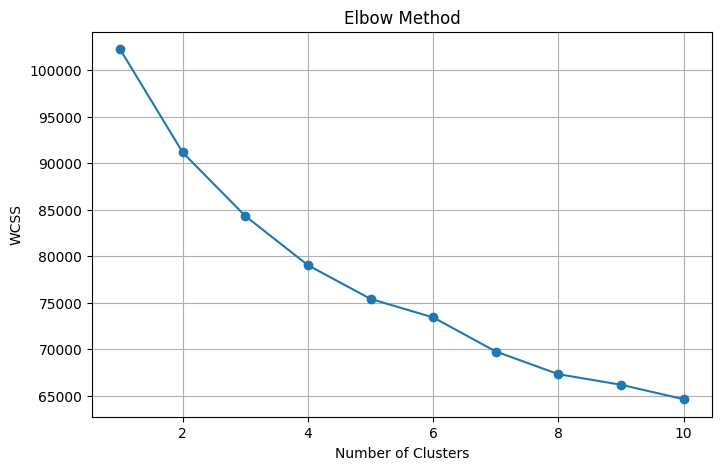

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Create K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Train model
clusters = kmeans.fit_predict(scaled_data)

# Add Cluster column
data["Cluster"] = clusters

# Check first few rows
data.head()

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,tower_number,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,Age,Cluster
0,1,0,9,8,0,4,1,2,9,0,40,1090.32,351419.29,0,58,1
1,1,0,9,8,0,4,1,2,4,0,51,1608.84,496266.41,0,58,3
2,1,0,9,8,0,4,1,2,15,0,15,522.71,175599.90,0,58,1
3,1,0,9,8,0,4,1,2,3,0,50,713.67,223479.12,0,58,1
4,1,1,9,8,0,1,0,2,15,0,6,938.57,299245.20,0,63,1


In [ ]:
print(data["Cluster"].value_counts())

Cluster
1    3306
3    2595
0    1023
2     381
Name: count, dtype: int64


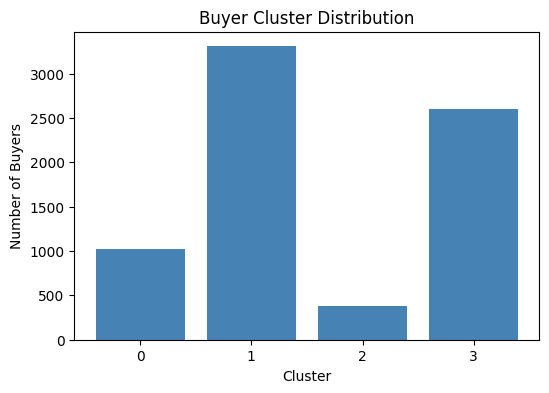

In [ ]:
import matplotlib.pyplot as plt

cluster_counts = data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values,
    color="steelblue"
)

plt.title("Buyer Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.12145424450853545


In [ ]:
cluster_summary = data.groupby("Cluster").mean(numeric_only=True)

display(cluster_summary)

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,tower_number,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,Age
Cluster,,,,,,,,,,,,,,,
0,1.0,0.507331,7.935484,21.119257,0.320626,3.019550,0.376344,1.174976,10.827957,1.000000,29.334311,1171.223891,368403.873118,0.0,56.824047
1,1.0,0.497278,7.863279,21.010587,0.305505,3.089232,0.365094,1.221416,8.928615,0.000000,27.949486,819.116050,244153.789274,0.0,56.425590
2,0.0,0.616798,8.081365,20.041995,0.383202,3.123360,0.393701,1.183727,10.188976,0.149606,27.921260,1131.178241,341644.645276,0.0,48.010499
3,1.0,0.510597,8.052408,20.962620,0.294027,3.006166,0.363006,1.206936,12.025819,0.000000,30.484393,1541.019788,464945.958170,0.0,56.450482


In [ ]:
data.to_csv("Real_Estate_Clustered.csv", index=False)

In [ ]:
from google.colab import files

files.download("Real_Estate_Clustered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
original_data = pd.read_csv("Cleaned_Real_Estate.csv")

In [ ]:
original_data["Cluster"] = clusters

In [ ]:
original_data.head()

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,Age,Cluster
0,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,9,2024-10-01,Apartment,40,1090.32,351419.29,Sold,58,1
1,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,4,2024-12-01,Apartment,51,1608.84,496266.41,Sold,58,3
2,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,15,2025-05-01,Apartment,15,522.71,175599.90,Sold,58,1
3,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,3,2025-12-01,Apartment,50,713.67,223479.12,Sold,58,1
4,Individual,1962-11-26,M,USA,California,Home,1,No,Website,15,2024-01-01,Apartment,6,938.57,299245.20,Sold,63,1


In [ ]:
original_data.to_csv("Real_Estate_Dashboard.csv", index=False)

In [ ]:
from google.colab import files

files.download("Real_Estate_Dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>